In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
base_path = r"C:\kdt_0900_hhj\ml\resource\dataset"
file_name = r"telecom_customer.csv"
file_path = os.path.join(base_path,file_name)

In [3]:
df = pd.read_csv(file_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 텔레콤 고객 이탈 데이터셋
[텔레콤 고객 이탈 데이터셋](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

## 텔레콤 고객 이탈 데이터셋 컬럼
| 컬럼명 | 설명 |
| :--- | :--- |
| customerID | 고객 고유 식별자 |
| gender | 성별 |
| SeniorCitizen | 고령자 여부 (65세 이상) |
| Partner | 배우자 유무 |
| Dependents | 부양가족 유무 |
| tenure | 서비스 가입 기간 (개월 수) |
| PhoneService | 전화 서비스 가입 여부 |
| MultipleLines | 다중 회선 사용 여부 |
| InternetService | 인터넷 서비스 제공 방식 |
| OnlineSecurity | 온라인 보안 서비스 이용 여부 |
| OnlineBackup | 온라인 백업 서비스 이용 여부 |
| DeviceProtection | 기기 보호 옵션 이용 여부 |
| TechSupport | 전담 기술 지원 서비스 이용 여부 |
| StreamingTV | 스트리밍 TV 서비스 이용 여부 |
| StreamingMovies | 스트리밍 영화 서비스 이용 여부 |
| Contract | 계약 형태 (월 단위, 1년, 2년) |
| PaperlessBilling | 전자 청구서 이용 여부 |
| PaymentMethod | 결제 수단 |
| MonthlyCharges | 월 청구 금액 |
| TotalCharges | 누적 총 청구 금액 |
| Churn | 고객 이탈 여부 (예측 대상) |

In [4]:
# 필요없는 아이디 데이터 없애기
telecom_df = df.drop("customerID", axis=1)
telecom_df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
telecom_df["TotalCharges"] = telecom_df["TotalCharges"].replace(r"^\s*$", np.nan, regex=True).astype(float)

In [6]:
telecom_df["TotalCharges"] = telecom_df["TotalCharges"].fillna(telecom_df["TotalCharges"].median())

-----------------------------------------------------------------------------------------------------------------------------

In [7]:
telecom_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [ ]:
# str타입인것들 정수로 변환

In [12]:
telecom_df["gender"] = telecom_df["gender"].replace({"Male": 1, "Female": 0}).astype(int)

In [9]:
#Yes,No로만 이루어진 컬럼 replace
yes_no_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
telecom_df[yes_no_cols] = telecom_df[yes_no_cols].replace({"Yes": 1, "No": 0}).astype(int)

In [13]:
#확인
telecom_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [14]:
# 종류가 yes,no만 있는것이 아닌 여러개를 가진 컬럼 원핫 인코딩
telecom_df = pd.get_dummies(
    telecom_df,
    columns=["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"],
    drop_first=True,
    dtype=int
)

In [16]:
# 다시 확인
telecom_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  MultipleLines_Y

In [17]:
# 상관관계 확인
corr_matrix = telecom_df.corr(numeric_only=True)
corr_matrix

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
gender,1.000000,-0.001874,-0.001808,0.010517,0.005106,-0.006488,-0.011754,-0.014569,-0.000002,-0.008612,...,-0.009212,0.006026,-0.008393,0.006026,-0.010487,0.008026,-0.003695,0.001215,0.000752,0.013744
SeniorCitizen,-0.001874,1.000000,0.016479,-0.211185,0.016567,0.008576,0.156530,0.220173,0.102652,0.150889,...,-0.060625,-0.182742,0.105378,-0.182742,0.120176,-0.046262,-0.117000,-0.024135,0.171718,-0.153477
Partner,-0.001808,0.016479,1.000000,0.452676,0.379697,0.017706,-0.014877,0.096848,0.318364,-0.150448,...,0.119999,0.000615,0.124666,0.000615,0.117412,0.082783,0.248091,0.082029,-0.083852,-0.095125
Dependents,0.010517,-0.211185,0.452676,1.000000,0.159712,-0.001762,-0.111377,-0.113890,0.063593,-0.164221,...,0.063268,0.139812,-0.016558,0.139812,-0.039741,0.068368,0.204613,0.060267,-0.150642,0.059071
tenure,0.005106,0.016567,0.379697,0.159712,1.000000,0.008448,0.006152,0.247900,0.825464,-0.352229,...,0.324221,-0.039062,0.279756,-0.039062,0.286111,0.202570,0.558533,0.233006,-0.208363,-0.233852
PhoneService,-0.006488,0.008576,0.017706,-0.001762,0.008448,1.000000,0.016505,0.247398,0.113013,0.011942,...,-0.096340,0.172209,-0.022574,0.172209,-0.032959,-0.002791,0.003519,-0.007721,0.003062,-0.003319
PaperlessBilling,-0.011754,0.156530,-0.014877,-0.111377,0.006152,0.016505,1.000000,0.352150,0.158055,0.191825,...,0.037880,-0.321013,0.223841,-0.321013,0.211716,-0.051391,-0.147889,-0.013589,0.208865,-0.205398
MonthlyCharges,-0.014569,0.220173,0.096848,-0.113890,0.247900,0.247398,0.352150,1.000000,0.650864,0.193356,...,0.338304,-0.763557,0.629603,-0.763557,0.627429,0.004904,-0.074681,0.030550,0.271625,-0.377437
TotalCharges,-0.000002,0.102652,0.318364,0.063593,0.825464,0.113013,0.158055,0.650864,1.000000,-0.199037,...,0.432329,-0.374706,0.515279,-0.374706,0.519884,0.170649,0.356226,0.182745,-0.059971,-0.294814
Churn,-0.008612,0.150889,-0.150448,-0.164221,-0.352229,0.011942,0.191825,0.193356,-0.199037,1.000000,...,-0.164674,-0.227890,0.063228,-0.227890,0.061382,-0.177820,-0.302253,-0.134302,0.301919,-0.091683


## 랜덤포레스트 실습

In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_squared_error

In [26]:
X = telecom_df.drop("Churn", axis=1)
print(X.head())
y = telecom_df["Churn"]
print(y.head())

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  \
0                 1           29.85         29.85   
1                 0           56.95       1889.50   
2                 1           53.85        108.15   
3                 0           42.30       1840.75   
4                 1           70.70        151.65   

   MultipleLines_No phone service  ...  TechSupport_Yes  \
0                               1  ...                0   
1                               0  ...                0   
2                               0  ...                0   
3                 

In [101]:
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5634, 32) (1409, 32) (5634,) (1409,)


In [28]:
# 표준화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
rf = RandomForestRegressor(random_state=2026)

In [40]:
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=2026)

In [41]:
y_pred = rf.predict(X_test)
y_pred

array([0.  , 0.01, 0.13, ..., 0.37, 0.31, 0.5 ], shape=(1409,))

In [32]:
rf.score(X_train, y_train)

0.8892376081300155

In [37]:
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")

RMSE: 0.37801629866530906


In [38]:
root_mean_squared_error(y_pred, y_test)
print(f"랜덤 포레스트 RMSE: {rmse}")

랜덤 포레스트 RMSE: 0.37801629866530906


In [42]:
# 각 feature 중요도

rf.feature_importances_

array([0.02523219, 0.01905908, 0.02014095, 0.01791924, 0.19026305,
       0.00240765, 0.02376767, 0.20249279, 0.20394503, 0.00283263,
       0.01584224, 0.09306603, 0.00152159, 0.00077426, 0.017278  ,
       0.00098019, 0.01897809, 0.00188311, 0.01398536, 0.00136514,
       0.01643655, 0.0012999 , 0.01098395, 0.00104352, 0.01124585,
       0.01484857, 0.0168415 , 0.0118525 , 0.02796084, 0.01375253])

In [45]:
features_imp = pd.DataFrame({
    "Features": X_train.columns,
    "importances": rf.feature_importances_
}).sort_values(by="importances", ascending=False)

features_imp


# TotalCharges,MonthlyCharges 가 가장 높은 영향

,Features,importances
8,TotalCharges,0.203945
7,MonthlyCharges,0.202493
4,tenure,0.190263
11,InternetService_Fiber optic,0.093066
28,PaymentMethod_Electronic check,0.027961
0,gender,0.025232
6,PaperlessBilling,0.023768
2,Partner,0.020141
1,SeniorCitizen,0.019059
16,OnlineBackup_Yes,0.018978


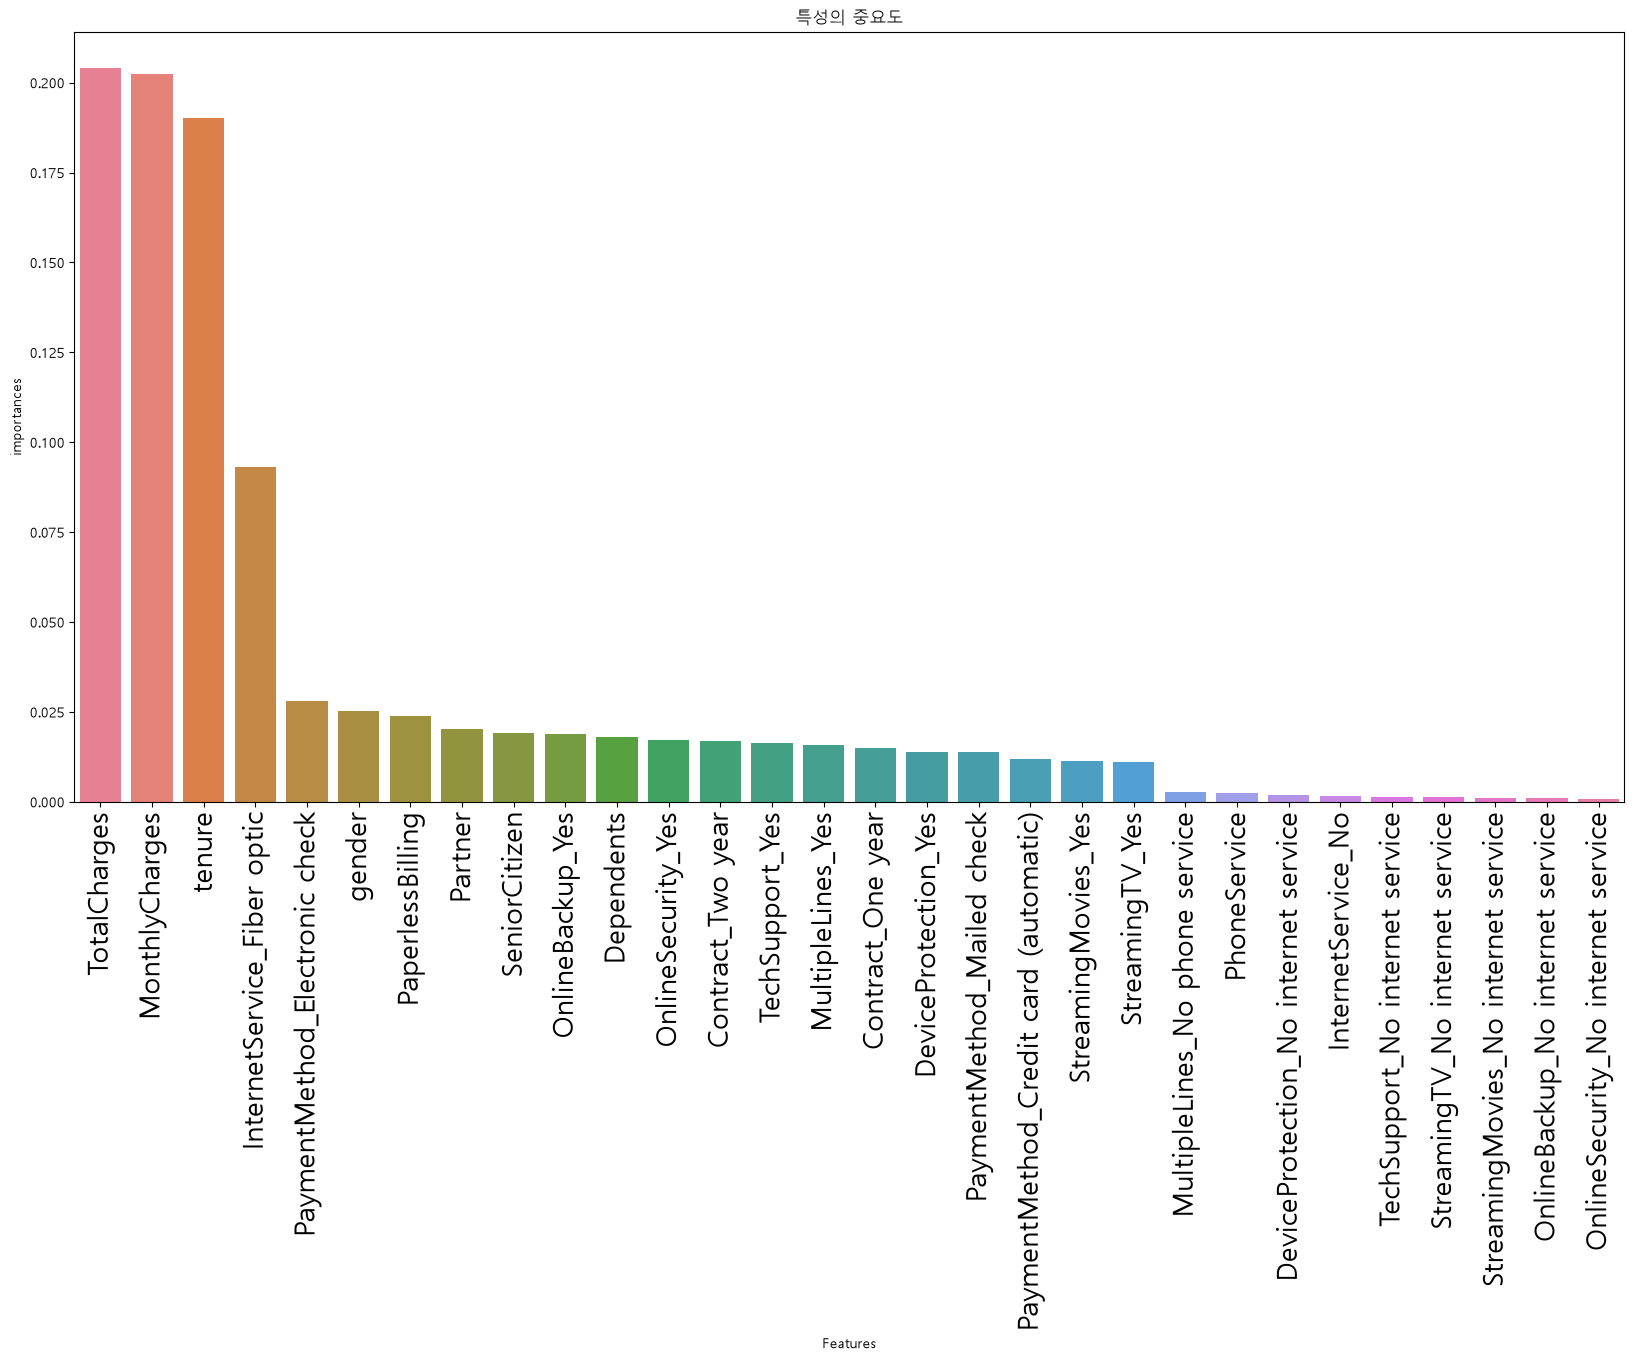

In [52]:
# 표로 보기
plt.figure(figsize=(20,10))
sns.barplot(features_imp, x="Features", y="importances", hue="Features")
plt.title("특성의 중요도")
plt.xticks(rotation=90, fontsize=20)
plt.show()

-------------------------------------------------------------------------------------------------------------------------------------

In [60]:
telecom_df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,84.80,1990.50,0,...,1,0,1,0,1,1,0,0,0,1
7039,0,0,1,1,72,1,1,103.20,7362.90,0,...,0,0,1,0,1,1,0,1,0,0
7040,0,0,1,1,11,0,1,29.60,346.45,0,...,0,0,0,0,0,0,0,0,1,0
7041,1,1,1,0,4,1,1,74.40,306.60,1,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
## 쌤 풀이

## 1단계, 데이터 전처리

## 파생변수 생성

In [56]:
telecom_df2 = df.drop("customerID", axis=1)
telecom_df2["TotalCharges"] = telecom_df2["TotalCharges"].replace(r"^\s*$", np.nan, regex=True).astype(float)
telecom_df2["TotalCharges"] = telecom_df2["TotalCharges"].fillna(telecom_df2["TotalCharges"].median())

In [61]:
# Partner와 Dependents를 합치기 0과 1로 

telecom_df2["FamilySize"] = (telecom_df2["Partner"] == "Yes").astype(int) + (telecom_df2["Dependents"] == "Yes").astype(int)

telecom_df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [64]:
service_columns = [
    "PhoneService", 
    "InternetService", 
    "OnlineSecurity", 
    "OnlineBackup",
    "DeviceProtection", 
    "TechSupport", 
    "StreamingTV", 
    "StreamingMovies"
]

# 총 서비스를 가입한 수
telecom_df2["TotalServices"] = (telecom_df2[service_columns] == "Yes").sum(axis=1)

In [73]:
telecom_df2.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,FamilySize,TotalServices
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,No,0,3
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0,3
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0,1


In [75]:
telecom_df2["Churn"] = (telecom_df2["Churn"] == "Yes").astype(int)

In [66]:
# 총 서비스의 개수마다 이탈률이 어느정도 분포되어 있는지

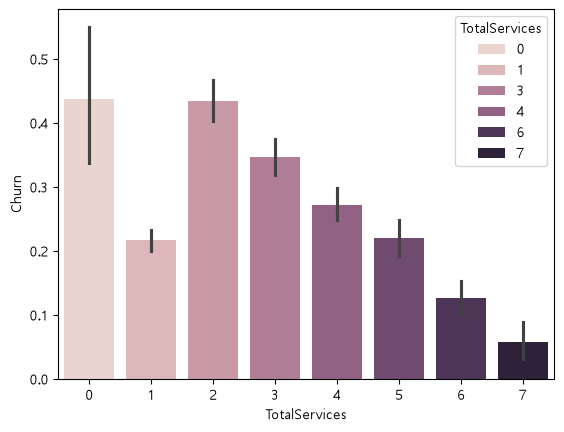

In [76]:
sns.barplot(telecom_df2, x="TotalServices", y="Churn", hue="TotalServices")
plt.show()

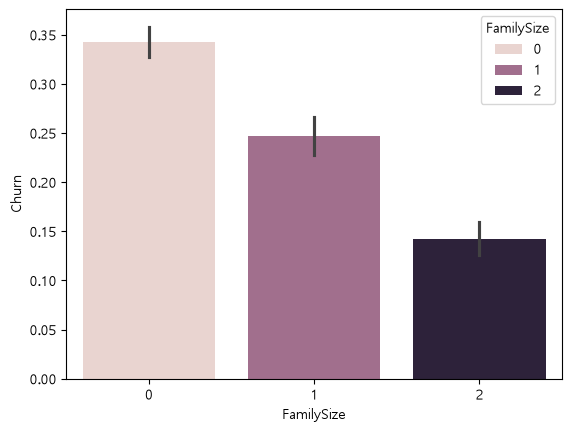

In [78]:
# 가족과 같이 가입한 사람들 가족수에따른 이탈률
sns.barplot(telecom_df2, x="FamilySize", y="Churn",  hue="FamilySize")
plt.show()

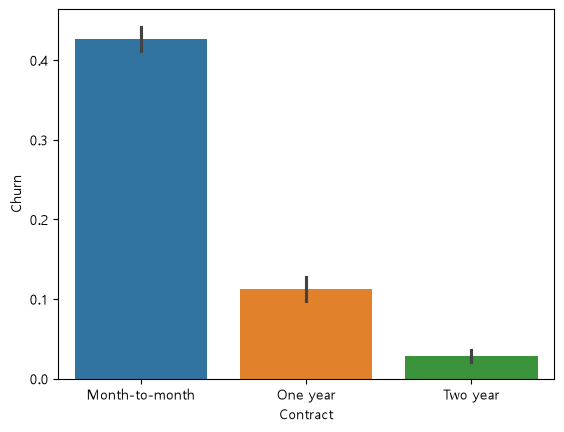

In [80]:
# 계약 유형별 이탈률
sns.barplot(telecom_df2, x="Contract", y="Churn",  hue="Contract")
plt.show()

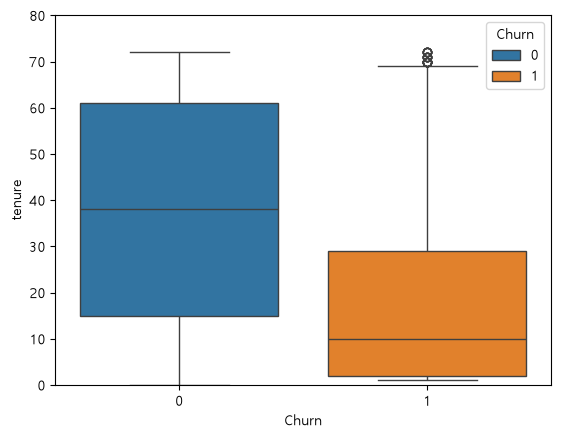

In [85]:
# 이탈 여부에 따른 가입기간 분포
sns.boxplot(telecom_df2, x="Churn", y="tenure", hue="Churn")
plt.ylim(0, 80)
plt.show()

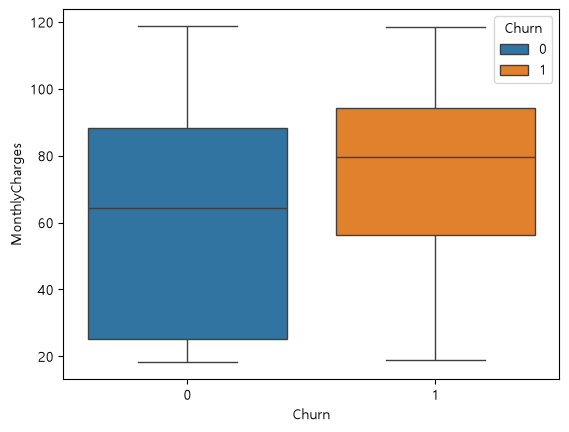

In [87]:
# 월에 청구되는 금액에 따른 이탈률
sns.boxplot(telecom_df2, x="Churn", y="MonthlyCharges", hue="Churn")
plt.show()

In [90]:
X = telecom_df2.drop("Churn", axis=1)
y = telecom_df2["Churn"]

In [95]:
for col in X.columns:
    print(f"{col:<20} 개수: {X[col].nunique()}개")
# 컬럼개수

gender               개수: 2개
SeniorCitizen        개수: 2개
Partner              개수: 2개
Dependents           개수: 2개
tenure               개수: 73개
PhoneService         개수: 2개
MultipleLines        개수: 3개
InternetService      개수: 3개
OnlineSecurity       개수: 3개
OnlineBackup         개수: 3개
DeviceProtection     개수: 3개
TechSupport          개수: 3개
StreamingTV          개수: 3개
StreamingMovies      개수: 3개
Contract             개수: 3개
PaperlessBilling     개수: 2개
PaymentMethod        개수: 4개
MonthlyCharges       개수: 1585개
TotalCharges         개수: 6531개
FamilySize           개수: 3개
TotalServices        개수: 8개


In [98]:
#원핫 인코딩
X = pd.get_dummies(X, drop_first=True, dtype=int)
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   FamilySize                             7043 non-null   int64  
 5   TotalServices                          7043 non-null   int64  
 6   gender_Male                            7043 non-null   int64  
 7   Partner_Yes                            7043 non-null   int64  
 8   Dependents_Yes                         7043 non-null   int64  
 9   PhoneService_Yes                       7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  MultipleLines_Y

In [99]:
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5634, 32) (1409, 32) (5634,) (1409,)


## 2단계, 모델준비

In [102]:
rf = RandomForestClassifier(n_estimators=100, n_jobs=1, random_state=2026)

In [103]:
rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=1, random_state=2026)

In [104]:
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

In [106]:
rf.score(X_test, y_test)

0.7934705464868701

In [107]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



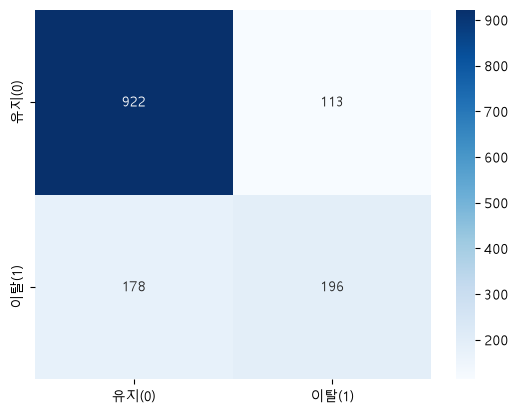

In [108]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xticks([0.5,1.5], ["유지(0)","이탈(1)"])
plt.yticks([0.5,1.5], ["유지(0)","이탈(1)"])
plt.show()

In [111]:
features_imp = pd.DataFrame({
    "Features": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

features_imp

,Features,Importance
3,TotalCharges,0.180574
1,tenure,0.171487
2,MonthlyCharges,0.154503
5,TotalServices,0.040994
12,InternetService_Fiber optic,0.036399
27,Contract_Two year,0.035625
30,PaymentMethod_Electronic check,0.031759
6,gender_Male,0.027364
28,PaperlessBilling_Yes,0.026399
4,FamilySize,0.023675


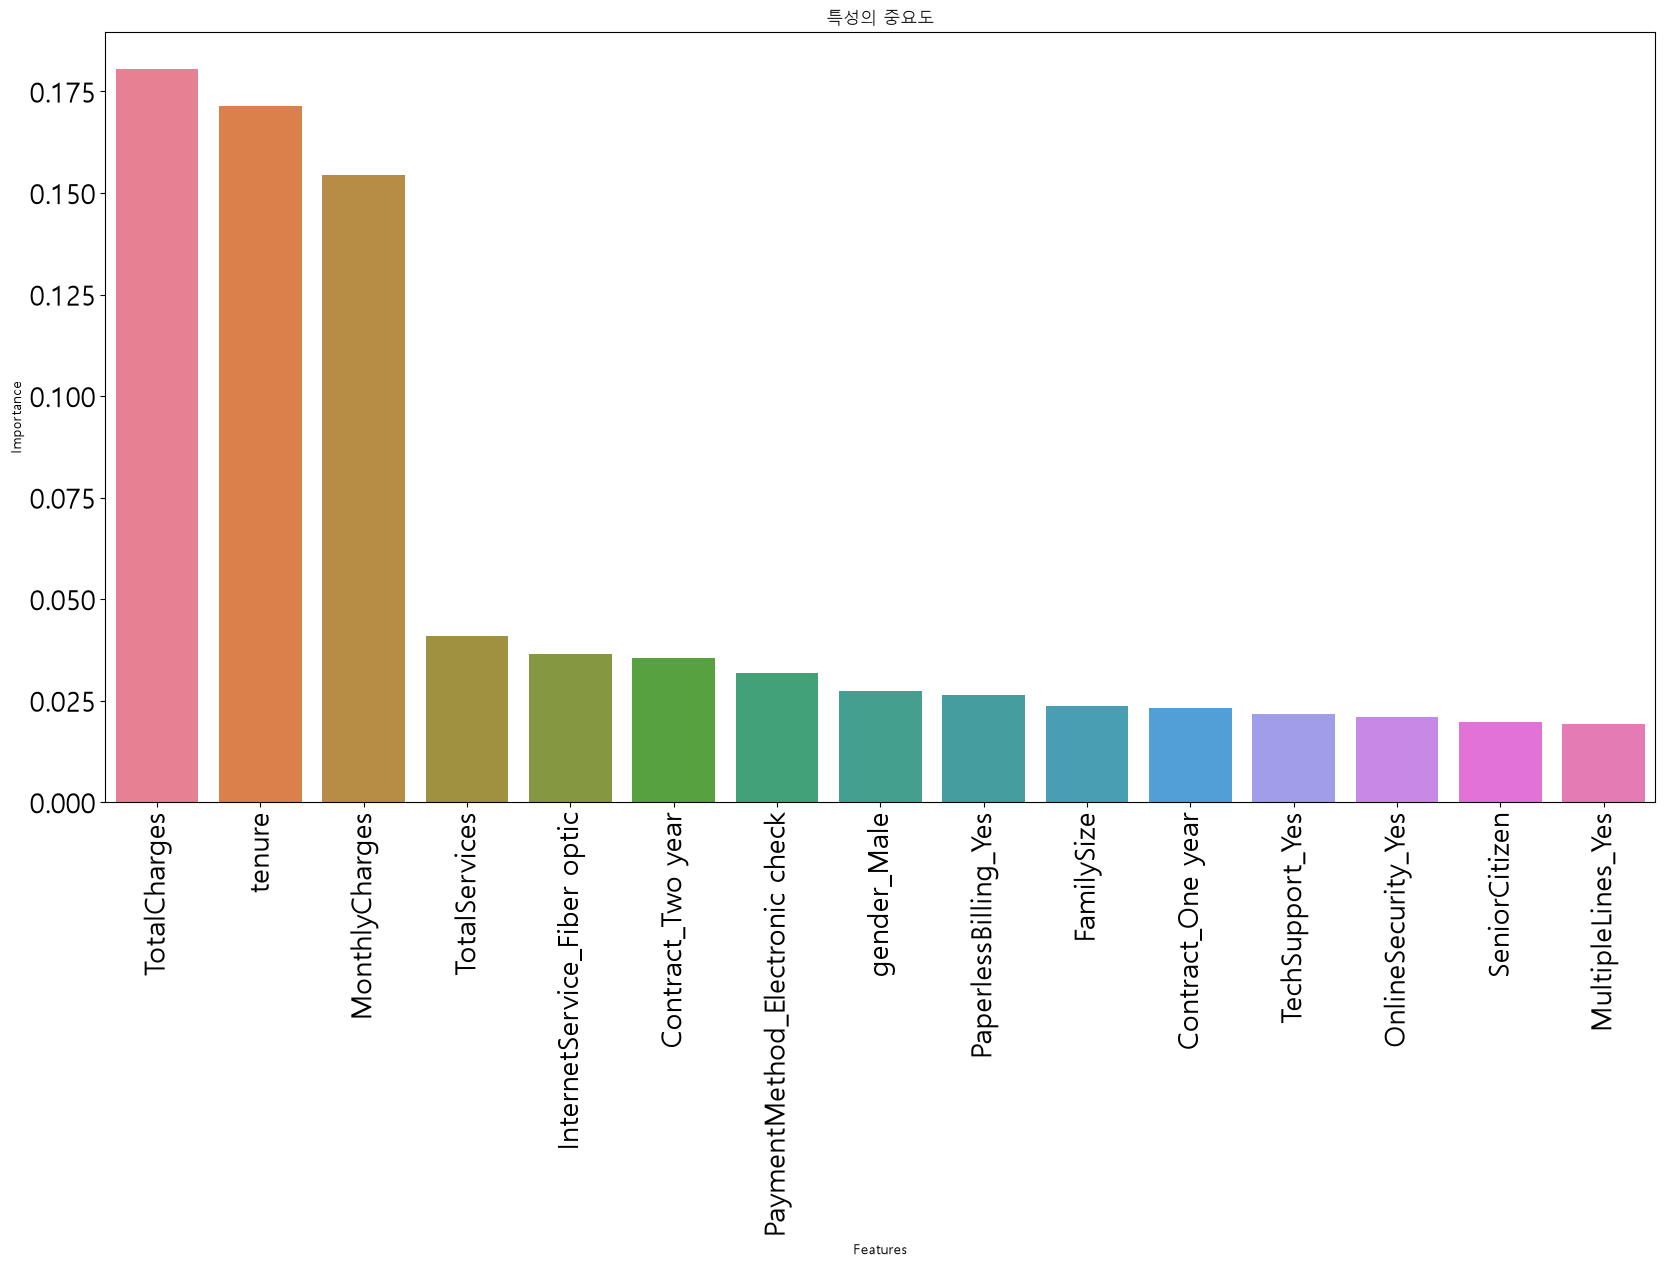

In [115]:
plt.figure(figsize=(20,10))
sns.barplot(features_imp.head(15), x="Features", y="Importance", hue="Features")
plt.title("특성의 중요도")
plt.xticks(rotation=90, fontsize=20)
plt.yticks(fontsize=20)
plt.show()